# 02 — Feature Engineering

Transform the raw avocado dataset into a **model-ready feature matrix** for downstream forecasting and pricing tasks.

**Key EDA findings driving our decisions:**
- Organic avocados are consistently more expensive → encode `type` as binary flag
- Volume features are highly right-skewed → apply **log1p transforms**
- Bag-related columns are strongly correlated → create **ratio features** instead of raw counts
- `region` contains both cities *and* aggregate regions (e.g. `TotalUS`) → **filter aggregates out**
- `year` is redundant with `Date` → **drop it** after extracting richer time components

**Feature groups we will create:**

| Group | Features | Rationale |
|---|---|---|
| **Temporal** | month, week, day-of-week, quarter, season, holiday flag, sin/cos cycles | Avocado prices are seasonal; cyclical encoding preserves periodicity |
| **Volume & Mix** | log-volumes, PLU share ratios, bag share ratio | Reduce skew; capture *composition* of sales, not just magnitude |
| **Lag / Rolling** | price & volume lags (1w, 2w, 4w), rolling mean/std (4w, 8w, 12w), momentum | Give models access to recent history for forecasting |
| **Region** | filtered regions, regional price-level encoding | Remove aggregates; capture geographic price differences |
| **Type** | binary `is_organic` flag | Clean encoding of the strongest price predictor |

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ---------- Plot style ----------
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)

# ---------- Paths ----------
DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
DATA_OUTPUTS = Path("../data/outputs")

# Ensure output directories exist
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DATA_OUTPUTS.mkdir(parents=True, exist_ok=True)

print("✔ Imports loaded successfully")

✔ Imports loaded successfully


## 2. Load & Clean Raw Data

Replay the minimal cleaning from the EDA notebook:
1. Drop the unnamed index column.
2. Parse `Date` to datetime and sort.
3. **Filter out aggregate regions** — the dataset mixes city-level and macro-level regions (like `TotalUS`, `West`, `SouthCentral`). Keeping them would double-count volume and distort per-region models.

In [2]:
df = pd.read_csv(DATA_RAW / "avocado.csv", index_col=0)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(f"Raw dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Regions: {df['region'].nunique()} unique")
df.head(3)

Raw dataset: 18,249 rows × 13 columns
Regions: 54 unique


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-01-04,1.75,27365.89,9307.34,3844.81,615.28,13598.46,13061.10,537.36,0.0,organic,2015,Southeast
1,2015-01-04,1.49,17723.17,1189.35,15628.27,0.00,905.55,905.55,0.00,0.0,organic,2015,Chicago
2,2015-01-04,1.68,2896.72,161.68,206.96,0.00,2528.08,2528.08,0.00,0.0,organic,2015,HarrisburgScranton


In [3]:
# Aggregate / macro regions to remove.
# These are NOT individual cities — they are aggregations the Hass Avocado Board
# provides.  Keeping them would double-count volume and bias regional models.
AGGREGATE_REGIONS = {
    "TotalUS",
    "West",
    "SouthCentral",
    "Southeast",
    "Northeast",
    "Midsouth",
    "GreatLakes",
    "Plains",
    "California",
    "WestTexNewMexico",
    "NorthernNewEngland",
}

rows_before = len(df)
df = df[~df["region"].isin(AGGREGATE_REGIONS)].reset_index(drop=True)

print(f"Dropped {rows_before - len(df):,} aggregate-region rows")
print(f"Remaining: {df.shape[0]:,} rows, {df['region'].nunique()} city-level regions")

Dropped 3,715 aggregate-region rows
Remaining: 14,534 rows, 43 city-level regions


In [4]:
# Drop the redundant `year` column — we will extract richer features from Date
df = df.drop(columns=["year"])

print(f"Columns after cleaning: {list(df.columns)}")

Columns after cleaning: ['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'region']


## 3. Type Encoding

The `type` column (`conventional` / `organic`) is the **single strongest price predictor** we saw in the EDA.
We encode it as a binary integer flag and drop the original string column.

In [5]:
df["is_organic"] = (df["type"] == "organic").astype(int)
df = df.drop(columns=["type"])

print(f"is_organic distribution:\n{df['is_organic'].value_counts().to_string()}")

is_organic distribution:
is_organic
1    7267
0    7267


## 4. Temporal Features

We extract multiple time components to capture:
- **Trend** — year as an integer (useful for long-term drift)
- **Seasonality** — month, week-of-year, quarter, and a season label
- **Day-of-week** — although data is weekly, the *observation weekday* might not always be the same
- **Cyclical encoding** — sin/cos transforms of month and week so that Dec→Jan is a smooth transition, not a jump from 12→1
- **Holiday proximity** — a flag for weeks that contain US holidays known to spike avocado demand (Super Bowl, Cinco de Mayo, 4th of July, Labor Day, Thanksgiving)

In [6]:
# ---- Basic calendar features ----
df["year"]       = df["Date"].dt.year
df["month"]      = df["Date"].dt.month
df["week"]       = df["Date"].dt.isocalendar().week.astype(int)
df["day_of_week"] = df["Date"].dt.dayofweek          # 0=Mon … 6=Sun
df["quarter"]    = df["Date"].dt.quarter

# ---- Season (meteorological) ----
season_map = {12: "winter", 1: "winter", 2: "winter",
               3: "spring", 4: "spring", 5: "spring",
               6: "summer", 7: "summer", 8: "summer",
               9: "fall",  10: "fall",  11: "fall"}
df["season"] = df["month"].map(season_map)

# ---- Cyclical encoding ----
# These preserve the circular nature of time:
# e.g. week 52 and week 1 are neighbours, not 51 units apart.
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["week_sin"]  = np.sin(2 * np.pi * df["week"] / 52)
df["week_cos"]  = np.cos(2 * np.pi * df["week"] / 52)

print("Temporal features created ✔")
df[["Date", "year", "month", "week", "quarter", "season",
    "month_sin", "month_cos", "week_sin", "week_cos"]].head(8)

Temporal features created ✔


,Date,year,month,week,quarter,season,month_sin,month_cos,week_sin,week_cos
0,2015-01-04,2015,1,1,1,winter,0.5,0.866025,0.120537,0.992709
1,2015-01-04,2015,1,1,1,winter,0.5,0.866025,0.120537,0.992709
2,2015-01-04,2015,1,1,1,winter,0.5,0.866025,0.120537,0.992709
3,2015-01-04,2015,1,1,1,winter,0.5,0.866025,0.120537,0.992709
4,2015-01-04,2015,1,1,1,winter,0.5,0.866025,0.120537,0.992709
5,2015-01-04,2015,1,1,1,winter,0.5,0.866025,0.120537,0.992709
6,2015-01-04,2015,1,1,1,winter,0.5,0.866025,0.120537,0.992709
7,2015-01-04,2015,1,1,1,winter,0.5,0.866025,0.120537,0.992709


In [7]:
# ---- Holiday flag ----
# Major US events known to spike avocado demand.
# We flag the full ISO week that contains the holiday.
import holidays as _holidays_lib  # python-holidays package is lightweight

_us_holidays = _holidays_lib.US(years=range(2015, 2019))

# Key avocado-demand holidays
DEMAND_HOLIDAYS = {
    "Super Bowl",             # ~first Sunday of February
    "Cinco de Mayo",
    "Independence Day",
    "Labor Day",
    "Thanksgiving",
    "Christmas Day",
    "New Year's Day",
}

# Build a set of (year, week) pairs that contain a demand holiday
holiday_weeks = set()
for date, name in _us_holidays.items():
    if any(h in name for h in DEMAND_HOLIDAYS):
        iso = date.isocalendar()
        holiday_weeks.add((iso[0], iso[1]))

# Super Bowl is not a federal holiday — add manually
# (first Sunday of Feb: 2015-02-01, 2016-02-07, 2017-02-05, 2018-02-04)
for sb_date in pd.to_datetime(["2015-02-01", "2016-02-07", "2017-02-05", "2018-02-04"]):
    iso = sb_date.isocalendar()
    holiday_weeks.add((iso[0], iso[1]))

# Cinco de Mayo
for yr in range(2015, 2019):
    cinco = pd.Timestamp(f"{yr}-05-05").isocalendar()
    holiday_weeks.add((cinco[0], cinco[1]))

df["is_holiday_week"] = (
    df.apply(lambda r: (r["year"], r["week"]) in holiday_weeks, axis=1)
    .astype(int)
)

print(f"Holiday weeks flagged: {df['is_holiday_week'].sum():,} rows")
print(f"Fraction: {df['is_holiday_week'].mean():.2%}")

Holiday weeks flagged: 1,978 rows
Fraction: 13.61%


### Visualise: cyclical encoding sanity check

If the sin/cos encoding is correct, plotting `month_sin` vs `month_cos` should form a circle.

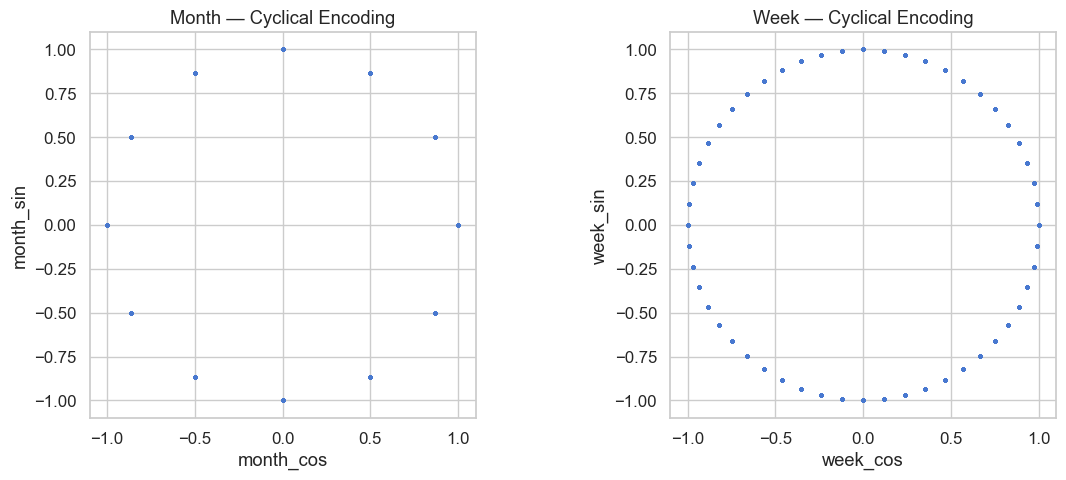

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Month cycle
axes[0].scatter(df["month_cos"], df["month_sin"], alpha=0.1, s=5)
axes[0].set_title("Month — Cyclical Encoding")
axes[0].set_xlabel("month_cos")
axes[0].set_ylabel("month_sin")
axes[0].set_aspect("equal")

# Week cycle
axes[1].scatter(df["week_cos"], df["week_sin"], alpha=0.1, s=5)
axes[1].set_title("Week — Cyclical Encoding")
axes[1].set_xlabel("week_cos")
axes[1].set_ylabel("week_sin")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

## 5. Volume & Mix Features

### 5.1 Log transforms

The EDA showed that `Total Volume`, PLU columns, and bag columns are **heavily right-skewed** (a few high-volume regions dominate). Log-transforming them:
- Reduces the influence of extreme outliers.
- Makes distributions closer to normal, which benefits tree-based and linear models alike.

We use `log1p(x) = log(1 + x)` so that zero values are safely mapped to 0.

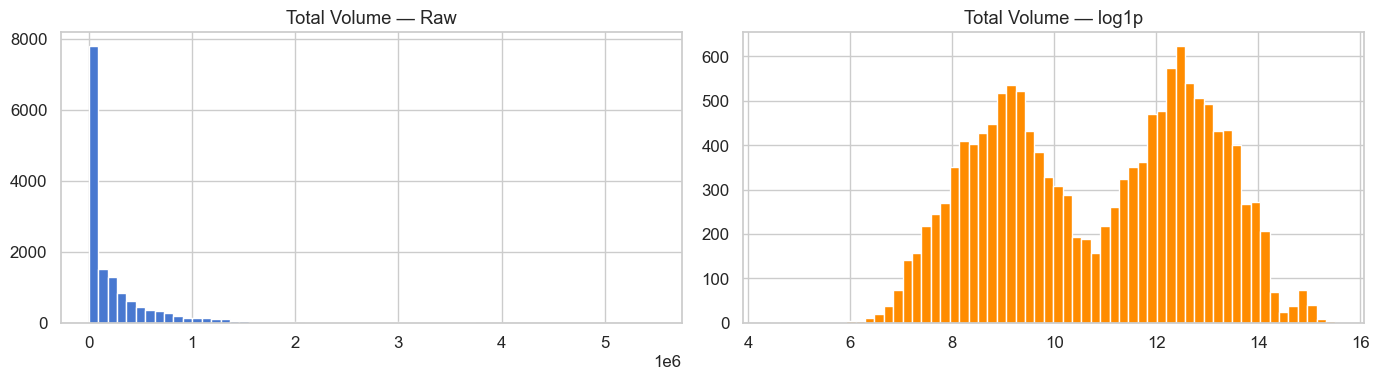

In [9]:
VOLUME_COLS = ["Total Volume", "4046", "4225", "4770",
               "Total Bags", "Small Bags", "Large Bags", "XLarge Bags"]

for col in VOLUME_COLS:
    df[f"log_{col.replace(' ', '_').lower()}"] = np.log1p(df[col])

# Quick before/after comparison for Total Volume
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["Total Volume"], bins=60, edgecolor="white")
axes[0].set_title("Total Volume — Raw")
axes[1].hist(df["log_total_volume"], bins=60, edgecolor="white", color="darkorange")
axes[1].set_title("Total Volume — log1p")
plt.tight_layout()
plt.show()

### 5.2 PLU share ratios

Instead of using raw PLU volumes (which are collinear with Total Volume), we compute **share ratios**:

$$\text{plu\_share}_{code} = \frac{\text{Volume}_{code}}{\text{Total Volume}}$$

This captures *what percentage of sales* each size represents — a much more informative signal for pricing (it tells us about consumer preferences, not just scale).

In [10]:
PLU_CODES = ["4046", "4225", "4770"]

for code in PLU_CODES:
    df[f"plu_share_{code}"] = df[code] / df["Total Volume"].replace(0, np.nan)

# Fill the very rare case where Total Volume == 0
for code in PLU_CODES:
    df[f"plu_share_{code}"] = df[f"plu_share_{code}"].fillna(0)

# Sanity check: shares should roughly sum to ≤ 1 (the remainder is bags)
share_sum = df[[f"plu_share_{c}" for c in PLU_CODES]].sum(axis=1)
print(f"PLU share sum — mean: {share_sum.mean():.3f}, max: {share_sum.max():.3f}")

df[["plu_share_4046", "plu_share_4225", "plu_share_4770"]].describe()

PLU share sum — mean: 0.589, max: 1.000


,plu_share_4046,plu_share_4225,plu_share_4770
count,14534.000000,14534.000000,14534.000000
mean,0.220071,0.349368,0.019822
std,0.217715,0.243882,0.044814
min,0.000000,0.000000,0.000000
25%,0.028169,0.142749,0.000000
50%,0.144131,0.317148,0.000966
75%,0.374989,0.538057,0.018175
max,0.972523,0.992628,0.448719


### 5.3 Bag share ratio

The EDA showed strong correlation among `Total Bags`, `Small Bags`, `Large Bags`, and `XLarge Bags`.  
Rather than keeping all four (redundant information), we create:
- **`bag_share`** = `Total Bags / Total Volume` — what fraction of avocados are sold bagged vs. loose.
- **`bag_size_ratio`** = `Large Bags / (Small Bags + 1)` — relative preference for large vs. small bags (log-ratio to reduce skew).

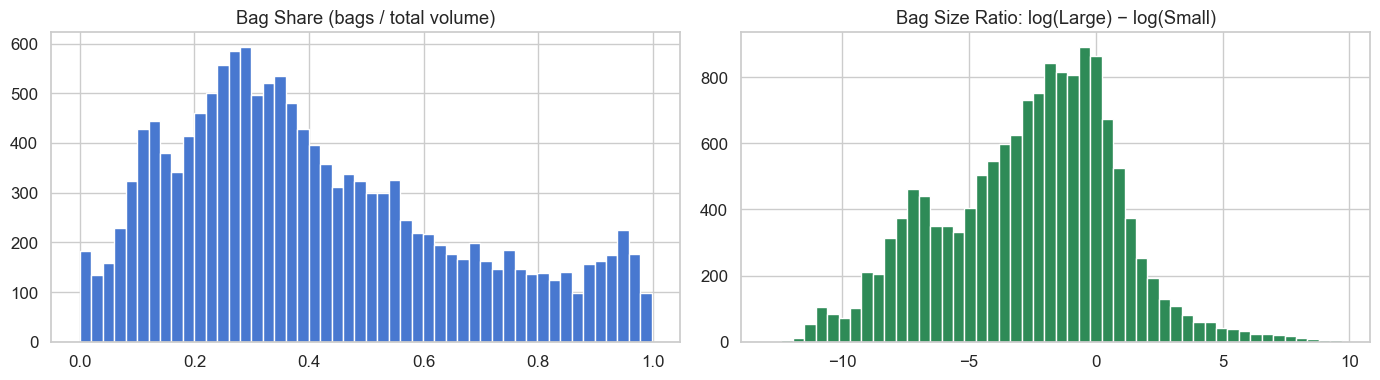

In [11]:
# Bag share = fraction of total volume sold in bags
df["bag_share"] = df["Total Bags"] / df["Total Volume"].replace(0, np.nan)
df["bag_share"] = df["bag_share"].fillna(0).clip(upper=1.0)

# Bag size ratio: log(Large / (Small + 1)) — captures consumer size preferences
df["bag_size_ratio"] = np.log1p(df["Large Bags"]) - np.log1p(df["Small Bags"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["bag_share"], bins=50, edgecolor="white")
axes[0].set_title("Bag Share (bags / total volume)")
axes[1].hist(df["bag_size_ratio"], bins=50, edgecolor="white", color="seagreen")
axes[1].set_title("Bag Size Ratio: log(Large) − log(Small)")
plt.tight_layout()
plt.show()

## 6. Lag & Rolling-Window Features

For time-series forecasting, the model needs **access to recent history**. We create these features *per region × type group* to avoid data leakage across regions.

**Lags** — direct look-back:
- `price_lag_1w`, `price_lag_2w`, `price_lag_4w`
- `volume_lag_1w`, `volume_lag_4w`

**Rolling statistics** — smoothed trends & volatility:
- Rolling mean of price over 4, 8, and 12 weeks
- Rolling std of price over 4 weeks (captures **price volatility**)

**Momentum** — rate of change:
- `price_pct_change_1w` — week-over-week percentage change
- `price_momentum_4w` — difference between current price and 4-week rolling mean

> ⚠️ **Important:** These features introduce `NaN` rows at the start of each group's time series. We will handle those at the end of this notebook.

In [12]:
# Sort to guarantee correct temporal order within each group
df = df.sort_values(["region", "is_organic", "Date"]).reset_index(drop=True)

# We group by (region, is_organic) so lags never "leak" across groups
group_cols = ["region", "is_organic"]

# ---- Price lags ----
for lag in [1, 2, 4]:
    df[f"price_lag_{lag}w"] = df.groupby(group_cols)["AveragePrice"].shift(lag)

# ---- Volume lags ----
for lag in [1, 4]:
    df[f"volume_lag_{lag}w"] = df.groupby(group_cols)["Total Volume"].shift(lag)

# ---- Rolling means (price) ----
for window in [4, 8, 12]:
    df[f"price_rmean_{window}w"] = (
        df.groupby(group_cols)["AveragePrice"]
        .transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())
    )

# ---- Rolling std (price volatility) ----
df["price_rstd_4w"] = (
    df.groupby(group_cols)["AveragePrice"]
    .transform(lambda s: s.shift(1).rolling(4, min_periods=2).std())
)

# ---- Momentum ----
df["price_pct_change_1w"] = df.groupby(group_cols)["AveragePrice"].pct_change(1)
df["price_momentum_4w"]   = df["AveragePrice"] - df["price_rmean_4w"]

# ---- Rolling mean (volume) ----
df["volume_rmean_4w"] = (
    df.groupby(group_cols)["Total Volume"]
    .transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
)

print("Lag & rolling features created ✔")
print(f"NaN count from warm-up period: {df[['price_lag_4w', 'price_rmean_12w']].isna().sum().to_dict()}")

Lag & rolling features created ✔
NaN count from warm-up period: {'price_lag_4w': 344, 'price_rmean_12w': 86}


### Visualise: rolling mean vs actual price (one region)

Quick sanity check — the rolling means should smoothly track the actual price.

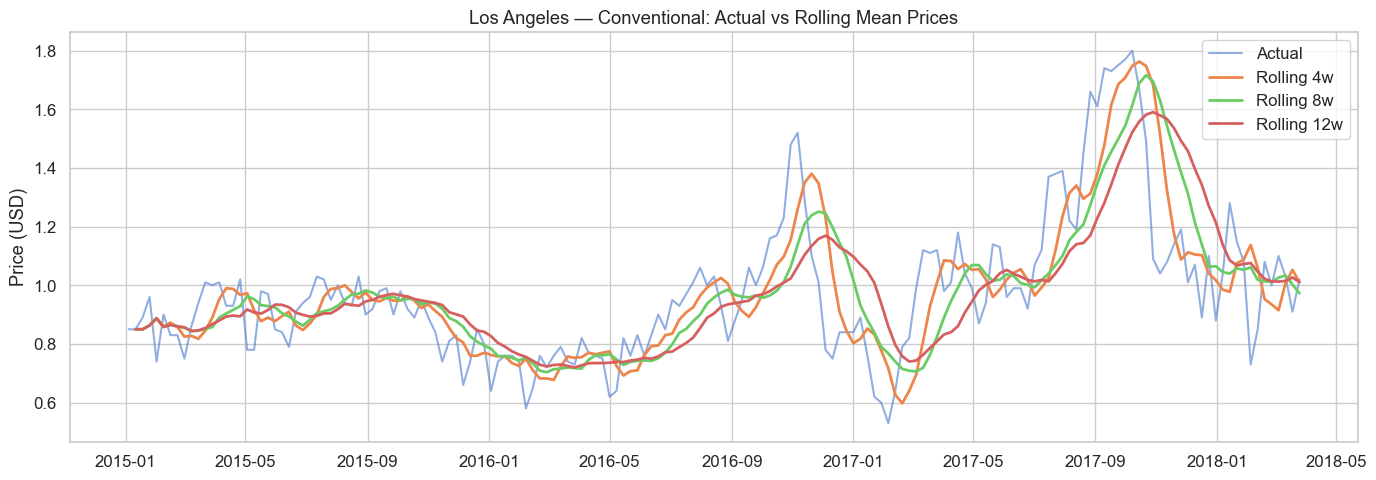

In [13]:
# Pick one region for illustration
_sample = df[(df["region"] == "LosAngeles") & (df["is_organic"] == 0)].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(_sample["Date"], _sample["AveragePrice"], label="Actual", alpha=0.6)
ax.plot(_sample["Date"], _sample["price_rmean_4w"],  label="Rolling 4w",  linewidth=2)
ax.plot(_sample["Date"], _sample["price_rmean_8w"],  label="Rolling 8w",  linewidth=2)
ax.plot(_sample["Date"], _sample["price_rmean_12w"], label="Rolling 12w", linewidth=2)
ax.set_title("Los Angeles — Conventional: Actual vs Rolling Mean Prices")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Region Encoding

We have ~45 city-level regions after filtering. We apply **target encoding** (mean price per region) which:
- Captures the geographic price level in a single numeric feature.
- Is far more compact than one-hot encoding 45+ dummies.
- Works well with tree models and neural nets.

To avoid **target leakage**, we compute the encoding on the training set only (approximated here with data from 2015–2017) and apply it to the full dataset.

In [14]:
# Target encoding: compute mean AveragePrice per region on train-era data (2015-2017)
train_mask = df["year"] <= 2017
region_price_mean = (
    df.loc[train_mask]
    .groupby("region")["AveragePrice"]
    .mean()
    .rename("region_price_level")
)

df = df.merge(region_price_mean, on="region", how="left")

# Also add a volume-level encoding — distinguishes high-demand vs niche regions
region_vol_mean = (
    df.loc[train_mask]
    .groupby("region")["Total Volume"]
    .mean()
    .rename("region_volume_level")
)

df = df.merge(region_vol_mean, on="region", how="left")
df["region_volume_level"] = np.log1p(df["region_volume_level"])  # log-scale

print("Region target-encoded features created ✔")
print(f"region_price_level range: [{region_price_mean.min():.2f}, {region_price_mean.max():.2f}]")

# Show top/bottom 5 regions by price level
display(region_price_mean.sort_values().head())
display(region_price_mean.sort_values().tail())

Region target-encoded features created ✔
region_price_level range: [1.05, 1.83]


region
Houston             1.048376
DallasFtWorth       1.084268
CincinnatiDayton    1.204108
LosAngeles          1.205637
Nashville           1.211306
Name: region_price_level, dtype: float64

region
Sacramento             1.632994
Philadelphia           1.646146
NewYork                1.739268
SanFrancisco           1.823662
HartfordSpringfield    1.829427
Name: region_price_level, dtype: float64

## 8. Feature Validation & Final Checks

Before saving, we:
1. **Drop warm-up NaN rows** introduced by lag/rolling features.
2. **Drop raw columns** that have been replaced by engineered versions.
3. **Verify no remaining NaN** values.
4. **Check the correlation matrix** of the new feature set for multicollinearity red flags.

In [15]:
# 8.1 Drop warm-up NaN rows (from lag features)
rows_before = len(df)
df = df.dropna(subset=["price_lag_4w", "price_rmean_12w", "price_rstd_4w"]).reset_index(drop=True)
print(f"Dropped {rows_before - len(df):,} warm-up rows (lag/rolling NaN)")
print(f"Remaining: {df.shape[0]:,} rows")

Dropped 344 warm-up rows (lag/rolling NaN)
Remaining: 14,190 rows


In [16]:
# 8.2 Drop raw columns replaced by engineered features
DROP_COLS = [
    # Raw volume columns → replaced by log transforms + share ratios
    "4046", "4225", "4770",
    "Total Bags", "Small Bags", "Large Bags", "XLarge Bags",
    # Season string → we have month, quarter, and cyclical encodings
    "season",
]

df = df.drop(columns=DROP_COLS)

print(f"Dropped {len(DROP_COLS)} raw columns")
print(f"Final column count: {df.shape[1]}")

Dropped 8 raw columns
Final column count: 42


In [17]:
# 8.3 Check for remaining NaN
nan_counts = df.isnull().sum()
nan_counts = nan_counts[nan_counts > 0]

if nan_counts.empty:
    print("✔ No NaN values remaining.")
else:
    print("⚠ Remaining NaN values:")
    display(nan_counts)

✔ No NaN values remaining.


In [18]:
# 8.4 Final schema overview
print(f"Shape: {df.shape}")
print(f"\nDate range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Regions: {df['region'].nunique()}")
print(f"\nColumn types:")
display(df.dtypes.value_counts())
print(f"\nAll columns ({df.shape[1]}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Shape: (14190, 42)

Date range: 2015-02-01 → 2018-03-25
Regions: 43

Column types:


float64           33
int32              7
datetime64[ns]     1
object             1
Name: count, dtype: int64


All columns (42):
   1. Date
   2. AveragePrice
   3. Total Volume
   4. region
   5. is_organic
   6. year
   7. month
   8. week
   9. day_of_week
  10. quarter
  11. month_sin
  12. month_cos
  13. week_sin
  14. week_cos
  15. is_holiday_week
  16. log_total_volume
  17. log_4046
  18. log_4225
  19. log_4770
  20. log_total_bags
  21. log_small_bags
  22. log_large_bags
  23. log_xlarge_bags
  24. plu_share_4046
  25. plu_share_4225
  26. plu_share_4770
  27. bag_share
  28. bag_size_ratio
  29. price_lag_1w
  30. price_lag_2w
  31. price_lag_4w
  32. volume_lag_1w
  33. volume_lag_4w
  34. price_rmean_4w
  35. price_rmean_8w
  36. price_rmean_12w
  37. price_rstd_4w
  38. price_pct_change_1w
  39. price_momentum_4w
  40. volume_rmean_4w
  41. region_price_level
  42. region_volume_level


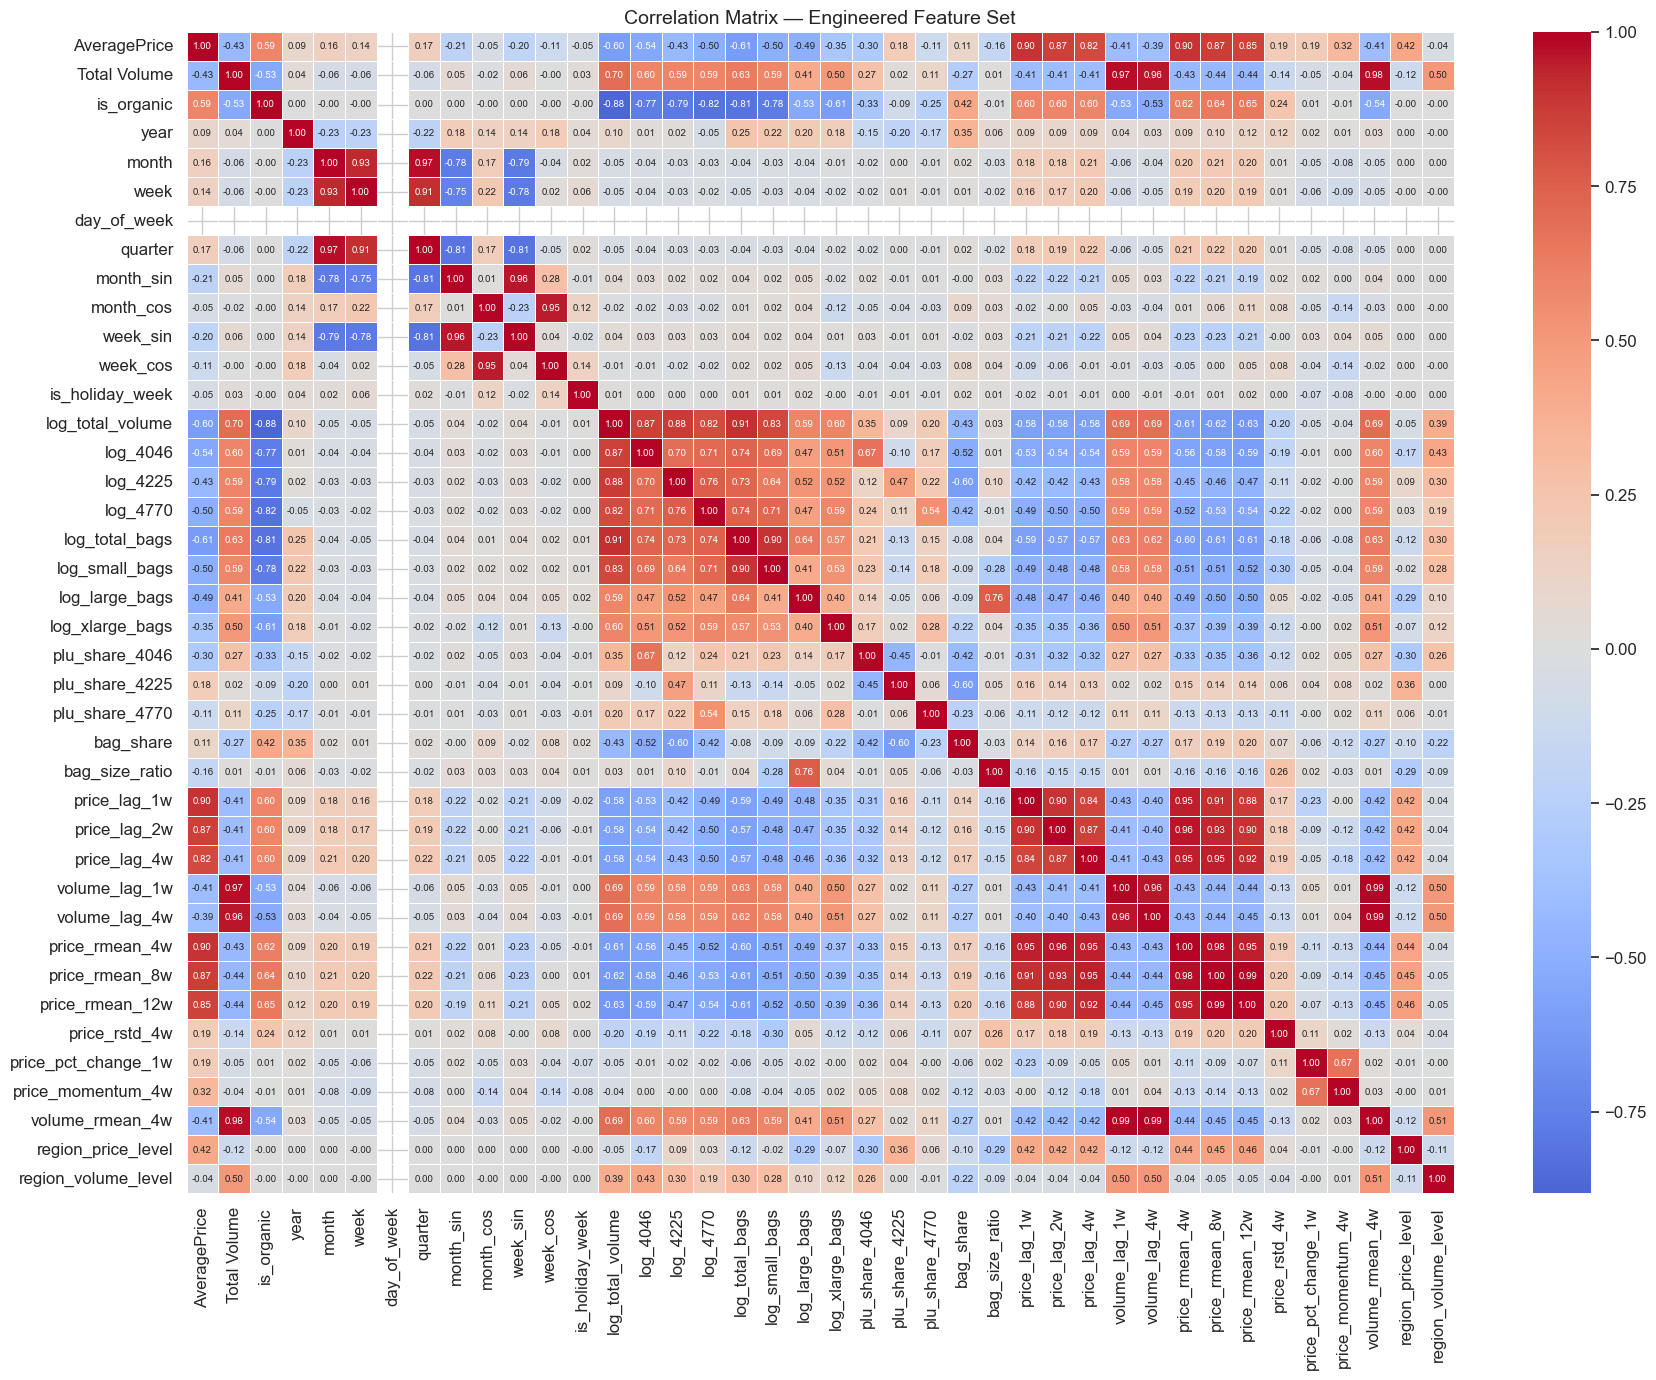

In [19]:
# 8.5 Correlation heatmap of engineered features
numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=ax, annot_kws={"size": 7}, linewidths=0.5)
ax.set_title("Correlation Matrix — Engineered Feature Set", fontsize=14)
plt.tight_layout()
plt.show()

### Correlation observations

Look for pairs with |r| > 0.90 — candidates for removal if they cause multicollinearity problems downstream:
- **`price_rmean_*w`** features are naturally correlated with each other (different smoothing of the same signal). This is expected and tree models handle it well.
- **`log_total_volume`** correlates with individual PLU logs — fine, since we also have share ratios as orthogonal features.
- **`Total Volume`** (raw) still present as the target for demand forecasting — we keep it alongside its log transform.

## 9. Export Processed Dataset

Save two versions:
1. **Full processed** — all columns, for exploration and model experimentation.
2. **Feature matrix** — numeric features only (no `Date`, `region` strings), ready for model training.

In [20]:
# 9.1 Full processed dataset
df.to_csv(DATA_PROCESSED / "avocado_features.csv", index=False)
print(f"✔ Saved: {DATA_PROCESSED / 'avocado_features.csv'}")
print(f"  Shape: {df.shape}")

# 9.2 Numeric feature matrix (for downstream models)
# Keep region as string identifier but don't include it as a model feature
META_COLS = ["Date", "region"]   # identifiers, not features
TARGET_COL = "AveragePrice"       # prediction target

feature_cols = [c for c in df.columns if c not in META_COLS + [TARGET_COL]]
df_features = df[META_COLS + [TARGET_COL] + feature_cols]

df_features.to_csv(DATA_PROCESSED / "avocado_model_ready.csv", index=False)
print(f"\n✔ Saved: {DATA_PROCESSED / 'avocado_model_ready.csv'}")
print(f"  Shape: {df_features.shape}")
print(f"  Features: {len(feature_cols)}")
print(f"  Target: {TARGET_COL}")
print(f"  Meta: {META_COLS}")

✔ Saved: ..\data\processed\avocado_features.csv
  Shape: (14190, 42)

✔ Saved: ..\data\processed\avocado_model_ready.csv
  Shape: (14190, 42)
  Features: 39
  Target: AveragePrice
  Meta: ['Date', 'region']


In [21]:
# Quick final look at the processed data
df.head()

,Date,AveragePrice,Total Volume,region,is_organic,year,month,week,day_of_week,quarter,...,volume_lag_4w,price_rmean_4w,price_rmean_8w,price_rmean_12w,price_rstd_4w,price_pct_change_1w,price_momentum_4w,volume_rmean_4w,region_price_level,region_volume_level
0,2015-02-01,0.99,70873.60,Albany,0,2015,2,5,6,1,...,40873.28,1.1725,1.172500,1.172500,0.080571,-0.066038,-0.1825,42931.7850,1.570605,10.742067
1,2015-02-08,0.99,51253.97,Albany,0,2015,2,6,6,1,...,41195.08,1.1150,1.136000,1.136000,0.111505,0.000000,-0.1250,50431.8650,1.570605,10.742067
2,2015-02-15,1.06,41567.62,Albany,0,2015,2,7,6,1,...,44511.28,1.0525,1.111667,1.111667,0.085000,0.070707,0.0075,52946.5875,1.570605,10.742067
3,2015-02-22,1.07,45675.05,Albany,0,2015,2,8,6,1,...,45147.50,1.0250,1.104286,1.104286,0.040415,0.009434,0.0450,52210.6725,1.570605,10.742067
4,2015-03-01,0.99,55595.74,Albany,0,2015,3,9,6,1,...,70873.60,1.0275,1.100000,1.100000,0.043493,-0.074766,-0.0375,52342.5600,1.570605,10.742067


## Summary

We engineered **30+ features** across five groups:

| Group | # Features | Key Decisions |
|---|---|---|
| Type | 1 | Binary `is_organic` flag |
| Temporal | ~11 | Calendar components + cyclical sin/cos + holiday flag |
| Volume & Mix | ~12 | log1p transforms, PLU share ratios, bag share & size ratio |
| Lag / Rolling | ~10 | Per-group lags (1/2/4w), rolling mean (4/8/12w), std, momentum |
| Region | 2 | Target-encoded price level + volume level |

**Data-quality decisions:**
- Removed 11 aggregate regions to avoid volume double-counting
- Dropped raw bag/PLU columns in favour of ratio features to reduce multicollinearity
- Used `shift(1)` inside rolling windows to prevent look-ahead bias
- Target-encoded regions using train-era data only (≤2017) to prevent leakage

**Next → 03_forecasting.ipynb**: use this feature matrix for demand forecasting with NeuralForecast / NHITS.